In [39]:
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
import cv2


In [40]:
df = pd.read_csv(r"D:\Saurabh Pandey\Wavelet_Analysis\dataset\00005.csv")

print(df.head())
print(df.columns)


   Voltage_measured  Current_measured  Temperature_measured  Current_load  \
0          4.186636         -0.001666              5.454957        0.0002   
1          4.186626         -0.002432              5.485011        0.0002   
2          4.001180         -0.995300              5.510369        1.0000   
3          3.982544         -0.994923              5.581233        1.0000   
4          3.968436         -0.995817              5.640744        1.0000   

   Voltage_load    Time  
0         0.000   0.000  
1         4.203   9.297  
2         3.431  23.265  
3         3.411  36.437  
4         3.398  49.609  
Index(['Voltage_measured', 'Current_measured', 'Temperature_measured',
       'Current_load', 'Voltage_load', 'Time'],
      dtype='str')


In [41]:
voltage = df["Voltage_measured"].values
current = df["Current_measured"].values
temperature = df["Temperature_measured"].values  # optional
time = df["Time"].values


In [42]:
# Estimate sampling period from time column
def estimate_fs(time_window):
    return 1 / np.median(np.diff(time_window))

fs = estimate_fs(time)

print("Estimated sampling frequency:", fs, "Hz")


Estimated sampling frequency: 0.07583225904299748 Hz


In [43]:
dt_all = np.diff(time)

print("Min dt:", np.min(dt_all))
print("Median dt:", np.median(dt_all))
print("Max dt:", np.max(dt_all))


Min dt: 9.297000000000004
Median dt: 13.186999999999898
Max dt: 13.967999999999996


In [44]:
def compute_cwt(signal, fs, wavelet="morl", scales=None):
    """
    signal  : 1D numpy array
    fs      : sampling frequency (Hz)
    wavelet : Morlet (recommended for battery signals)
    scales  : wavelet scales
    """
    if scales is None:
        scales = np.arange(1, 128)

    coeffs, freqs = pywt.cwt(
        signal,
        scales,
        wavelet,
        sampling_period=1/fs
    )

    return coeffs, freqs
# Compute CWT for voltage signal
coeffs, freqs = compute_cwt(voltage, fs)
print("CWT shape:", coeffs.shape)


CWT shape: (127, 429)


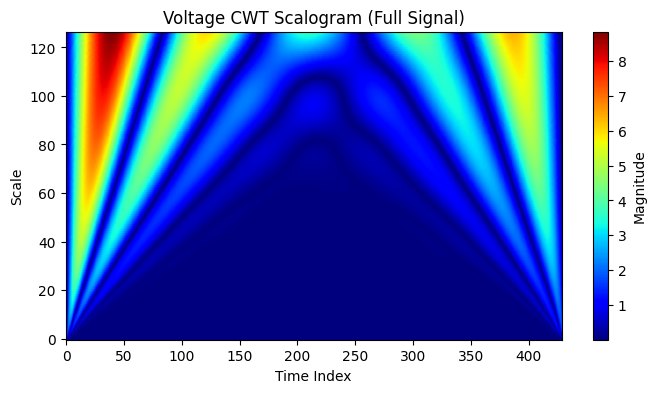

In [45]:
coeff_v, freq_v = compute_cwt(voltage, fs)

plt.figure(figsize=(8,4))
plt.imshow(
    np.abs(coeff_v),
    aspect="auto",
    cmap="jet",
    origin="lower"
)
plt.colorbar(label="Magnitude")
plt.xlabel("Time Index")
plt.ylabel("Scale")
plt.title("Voltage CWT Scalogram (Full Signal)")
plt.show()


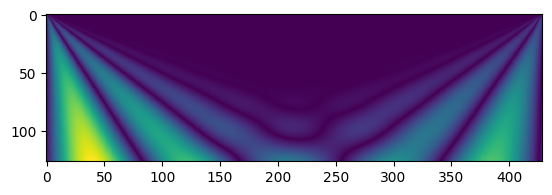

In [46]:
plt.imshow(np.abs(coeff_v))


In [47]:
window_size = 256   # samples
stride = 128        # 50% overlap

def create_windows(signal, window_size, stride):
    windows = []
    for i in range(0, len(signal) - window_size, stride):
        windows.append(signal[i:i + window_size])
    return np.array(windows)


In [48]:
voltage_windows = create_windows(voltage, window_size, stride)
current_windows = create_windows(current, window_size, stride)
temperature_windows = create_windows(temperature, window_size, stride)

print("Total windows:", voltage_windows.shape[0])


Total windows: 2


In [49]:
def temperature_scalar(temp_window):
    return np.mean(temp_window)



In [50]:
X = []          # CWT images
T_scalar = []   # temperature scalar
y = []


In [51]:
def cwt_to_image(signal, fs, img_size=(224, 224)):
    scales = np.arange(1, 128)
    coeffs, _ = pywt.cwt(signal, scales, "morl", sampling_period=1/fs)

    scalogram = np.abs(coeffs)

    # Normalize to [0,1]
    scalogram = (scalogram - scalogram.min()) / (scalogram.max() - scalogram.min())

    # Resize for CNN
    scalogram = cv2.resize(scalogram, img_size)

    return scalogram
# Example: Convert first voltage window to image

In [52]:

for v_win, i_win, t_win in zip(
        voltage_windows,
        current_windows,
        temperature_windows,
        ):

    img_v = cwt_to_image(v_win, fs)
    img_i = cwt_to_image(i_win, fs)
    cwt_img = np.stack([img_v, img_i], axis=-1)

    X.append(cwt_img)
    T_scalar.append(np.mean(t_win))     # temperature scalar
    # y.append(np.mean(soc_win))


X = np.array(X)                 # (N, 224, 224, 2)
T_scalar = np.array(T_scalar)   # (N,)
# y = np.array(y)

print("Final dataset shape (windows, height, width, channels):", X.shape)

Final dataset shape (windows, height, width, channels): (2, 224, 224, 2)


In [53]:
T_scalar = (T_scalar - T_scalar.mean()) / T_scalar.std()


In [54]:
np.save("X_cwt.npy", X)
np.save("T_scalar.npy", T_scalar)


In [ ]:
wavelet_image = cv2.resize(scalogram, (224, 224))


In [ ]:
# Plot example scalogram from first voltage window (or full signal fallback)
if 'voltage_windows' in globals() and len(voltage_windows) > 0:
    scalogram = cwt_to_image(voltage_windows[0], fs, img_size=(224,224))
else:
    scales = np.arange(1, 128)
    coeffs, freqs = pywt.cwt(voltage, scales, 'morl', sampling_period=1/fs)
    scalogram = np.abs(coeffs)
    scalogram = (scalogram - scalogram.min()) / (scalogram.max() - scalogram.min())
plt.figure(figsize=(6, 5))
plt.imshow(scalogram, cmap="jet", aspect="auto", origin="lower")
plt.colorbar(label="Normalized Magnitude")
plt.xlabel("Time")
plt.ylabel("Scale (Frequency)")
plt.title("Wavelet Image (CWT Scalogram)")
plt.tight_layout()
plt.show()


NameError: name 'scalogram' is not defined

<Figure size 600x500 with 0 Axes>